# Smart Home Energy Simulation

This notebook provides an interactive object-oriented model for energy simulation. You can define components like PV systems, batteries, and heat pumps, and then run simulations to analyze energy balance and costs.

## 1. Simulation Logic
Define the base classes for components and the simulation engine.

In [1]:
import importlib, simulation
importlib.reload(simulation)
from simulation import *
import pandas as pd, numpy as np
print('simulation.py loaded.')


simulation.py loaded.


## 2. Setup & Run Baseline
Initialize and execute the **Base Case**.

In [2]:
from simulation import setup_base, run_scenario, show_comparison
import pandas as pd, numpy as np

# Default duration — old scenario cells (Cell 6/8) use these variables.
# They get overridden when run_scenario() is called with explicit duration_days.
duration_days = 1
steps_per_day = 4
dt            = 24.0 / steps_per_day
total_steps   = steps_per_day * duration_days

print(f'Ready. Default: {duration_days} day(s), {total_steps} steps x {dt:.1f} h each.')


Ready. Default: 1 day(s), 4 steps x 6.0 h each.


## 3. Scenario Adjustment
Define multipliers for the scenario.

In [3]:
pv_factor = 0.0     # 0% PV (no solar available)
battery_factor = 0.2 # 80% reduction
print(f"FACTORS: PV x{pv_factor}, Battery x{battery_factor}")

FACTORS: PV x0.0, Battery x0.2


## 4. Run Scenario
Execute the simulation with the adjusted parameters.

In [4]:
# ── First Scenario (no PV, reduced battery) ──────────────────
base_summary, scenario_summary = run_scenario(
    duration_days  = duration_days,
    season         = 'winter',
    pv_factor      = pv_factor,
    battery_factor = battery_factor,
)
print(f'SCENARIO RUN: {duration_days} day(s)')
for k, v in scenario_summary.items(): print(f'  {k:28}: {v:8.2f}')



--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=2.875 
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacity=0.0    Efficiency=1.0   
HeatPump    : Capacity=3.0    Efficiency=3.5   
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=2.0    MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.27   ExportPrice=0.08  
--------------------------------------------------

SCENARIO RUN: 1 day(s)
  Total Cost (CHF)            :    12.84
  Total Emissions (kg CO2)    :    18.88
  PV Generation (kWh)         :     0.00
  Heat Demand (kWh)           :    69.00
  Heat Supplied (kWh)         :    69.00
  Cooling Demand (kWh)        :     0.00
  Cooling Supplied (kWh)      :     0.00
  Elec Demand (kWh)           :    45.00
  Elec Supplied (kWh)         :   

## 5. Comparison Matrix
Visualize the analytics: **SCR** (Self-Consumption), **SSR** (Self-Sufficiency), and **Comfort**.

In [5]:
import pandas as pd, numpy as np

def calculate_comp(base, scen):
    res = []
    for m in base:
        b, s = base[m], scen[m]
        dev = ((s-b)/abs(b)*100) if b != 0 else (0.0 if s == 0 else float('nan'))
        res.append({'Metric': m, 'Base': b, 'Scenario': s, 'Rel. Dev. (%)': dev})
    return pd.DataFrame(res)

def color_dev(v):
    if pd.isna(v) or v == 0: return 'background-color:#3b82f6;color:white'
    return 'background-color:#22c55e;color:white' if v > 0 else 'background-color:#ef4444;color:white'

def show_comparison(base, scen, title='Comparison'):
    print(f'--- {title} ---')
    df = calculate_comp(base, scen)
    return df.style.map(color_dev, subset=['Rel. Dev. (%)']).format(
        {'Base': '{:.2f}', 'Scenario': '{:.2f}', 'Rel. Dev. (%)': '{:+.2f}%'})


## Heat Wave
set parameters to Heat Wave Scneario

In [6]:
# ════════════════════════════════════════════════════════════
# SCENARIO  —  edit values, then run this cell
# ════════════════════════════════════════════════════════════
sweep_results_hw = run_pv_sweep_scenario(
    duration_days           = 30,
    season                  = 'summer',  # <--- set season to summer
    pv_factor               = 0.70,
    battery_factor          = 0.10,
    heat_demand_factor      = 1.0,   # 2.0 = coldspell
    cooling_demand_factor   = 2.0,   # 2.0 = heatwave
    elec_demand_factor      = 1.0,
    hp_capacity_factor      = 1.0,
    chiller_capacity_factor = 1.0,
    boiler_capacity_factor  = 1.0,
    heat_storage_factor     = 1.0,
    black_out_factor        = False,
    grid_import_price_factor = 1.0,
    grid_export_price_factor = 1.0,
)



RUNNING SWEEP: PV Sizing Factor = 1.2x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=0.35  
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=4.0   
PV          : Capacity=3.345263157894737 Efficiency=1.0   
HeatPump    : Capacity=3.0    Efficiency=3.5   
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=1.0    MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.27   ExportPrice=0.08  
--------------------------------------------------


RUNNING SWEEP: PV Sizing Factor = 1.0x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=0.35  
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=4.0   
PV          : Capacity=2.787719298245614 Effi


--- Heatwave vs Base ---

PV Sizing: 1.2x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),-18.52,150.04,+909.98%
1,Total Emissions (kg CO2),1.06,227.63,+21432.28%
2,PV Generation (kWh),1634.40,1144.08,-30.00%
3,Heat Demand (kWh),252.00,252.00,+0.00%
4,Heat Supplied (kWh),252.00,252.00,+0.00%
5,Cooling Demand (kWh),1440.00,2880.00,+100.00%
6,Cooling Supplied (kWh),1440.00,2340.00,+62.50%
7,Elec Demand (kWh),1365.50,1665.50,+21.97%
8,Elec Supplied (kWh),1365.50,1665.50,+21.97%
9,Grid Import (kWh),2.64,569.07,+21432.28%



PV Sizing: 1.0x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),9.13,191.75,+2001.21%
1,Total Emissions (kg CO2),13.52,284.07,+2001.21%
2,PV Generation (kWh),1362.00,953.40,-30.00%
3,Heat Demand (kWh),252.00,252.00,+0.00%
4,Heat Supplied (kWh),252.00,252.00,+0.00%
5,Cooling Demand (kWh),1440.00,2880.00,+100.00%
6,Cooling Supplied (kWh),1440.00,2340.00,+62.50%
7,Elec Demand (kWh),1365.50,1664.15,+21.87%
8,Elec Supplied (kWh),1365.50,1664.15,+21.87%
9,Grid Import (kWh),33.80,710.18,+2001.21%



PV Sizing: 0.8x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),75.89,243.40,+220.75%
1,Total Emissions (kg CO2),112.42,360.60,+220.75%
2,PV Generation (kWh),1089.60,762.72,-30.00%
3,Heat Demand (kWh),252.00,252.00,+0.00%
4,Heat Supplied (kWh),252.00,252.00,+0.00%
5,Cooling Demand (kWh),1440.00,2880.00,+100.00%
6,Cooling Supplied (kWh),1440.00,2340.00,+62.50%
7,Elec Demand (kWh),1365.50,1664.78,+21.92%
8,Elec Supplied (kWh),1365.50,1664.78,+21.92%
9,Grid Import (kWh),281.06,901.49,+220.75%



PV Sizing: 0.6x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),145.75,294.38,+101.97%
1,Total Emissions (kg CO2),215.93,436.11,+101.97%
2,PV Generation (kWh),817.20,572.04,-30.00%
3,Heat Demand (kWh),252.00,252.00,+0.00%
4,Heat Supplied (kWh),252.00,252.00,+0.00%
5,Cooling Demand (kWh),1440.00,2880.00,+100.00%
6,Cooling Supplied (kWh),1440.00,2340.00,+62.50%
7,Elec Demand (kWh),1362.72,1662.89,+22.03%
8,Elec Supplied (kWh),1362.72,1662.89,+22.03%
9,Grid Import (kWh),539.82,1090.28,+101.97%



--- Absolute Comparison (Scenario Values) ---


PV Sizing,Metric,1.2x,1.0x,0.8x,0.6x
15,Total Cost (CHF),150.04,191.75,243.40,294.38
16,Total Emissions (kg CO2),227.63,284.07,360.60,436.11
12,PV Generation (kWh),1144.08,953.40,762.72,572.04
10,Heat Demand (kWh),252.00,252.00,252.00,252.00
11,Heat Supplied (kWh),252.00,252.00,252.00,252.00
1,Cooling Demand (kWh),2880.00,2880.00,2880.00,2880.00
2,Cooling Supplied (kWh),2340.00,2340.00,2340.00,2340.00
4,Elec Demand (kWh),1665.50,1664.15,1664.78,1662.89
5,Elec Supplied (kWh),1665.50,1664.15,1664.78,1662.89
8,Grid Import (kWh),569.07,710.18,901.49,1090.28


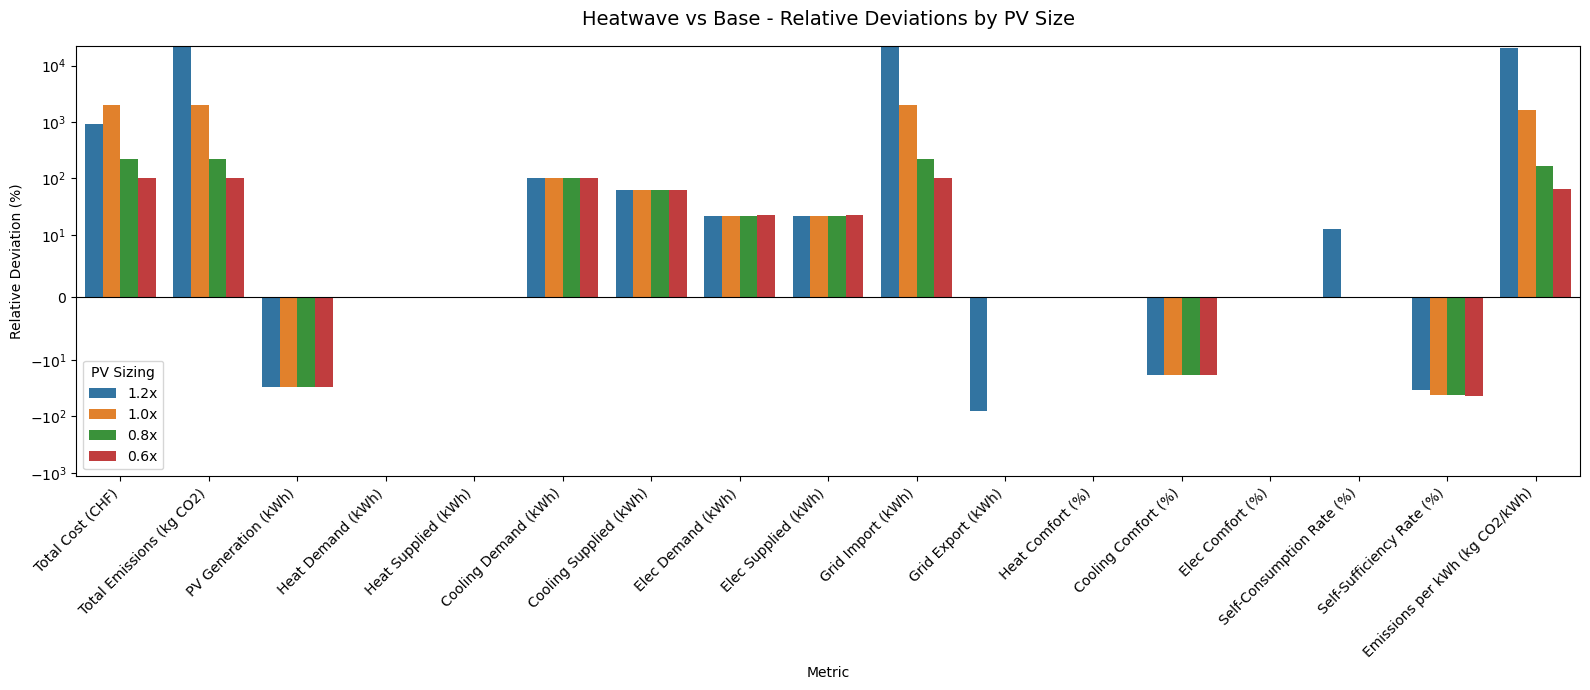

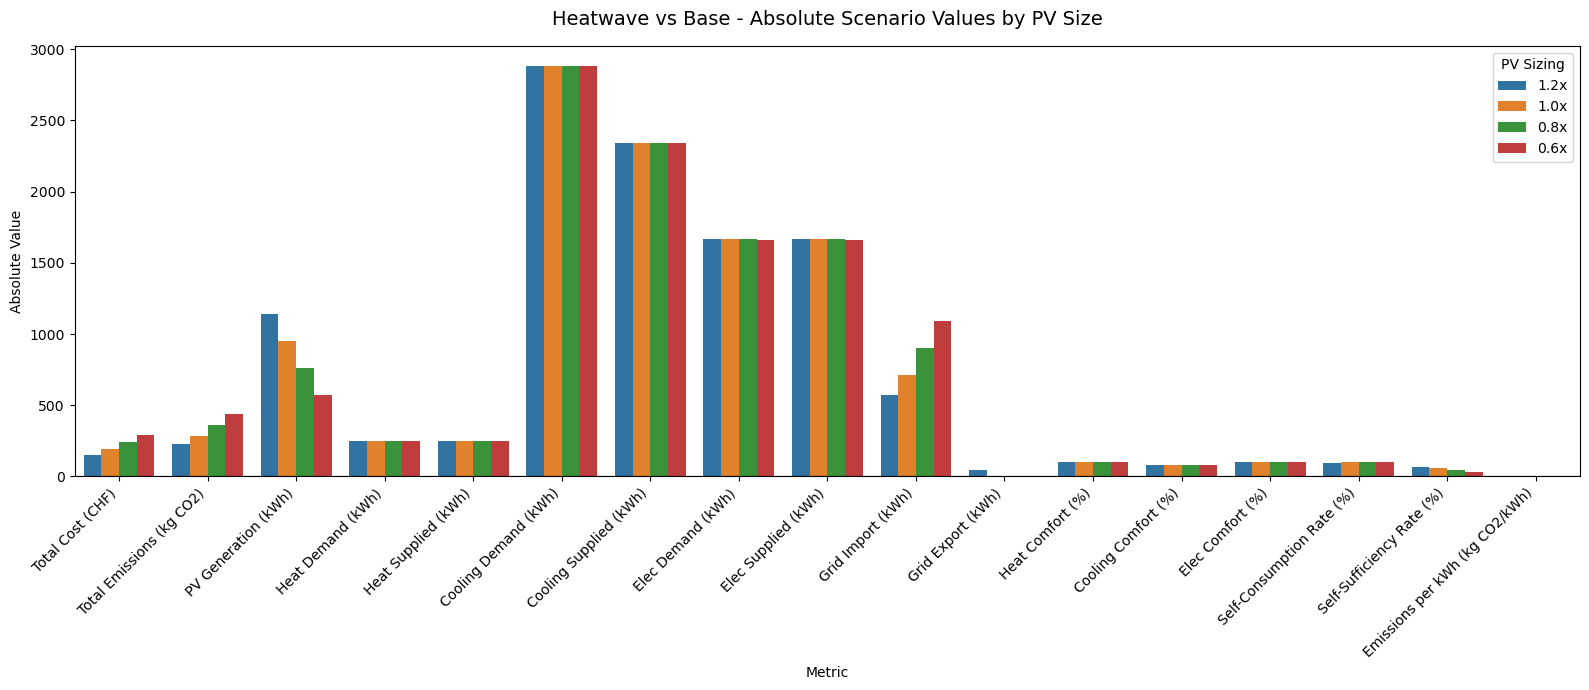

In [7]:
show_sweep_comparison(sweep_results_hw, 'Heatwave vs Base')


## Cold Spell Scenario
Set parameters for a cold spell event (low temperatures, high heat demand, reduced PV).

In [8]:
# ════════════════════════════════════════════════════════════
# COLD SPELL SCENARIO  —  edit values, then run this cell
# ════════════════════════════════════════════════════════════
sweep_results_cs = run_pv_sweep_scenario(
    duration_days           = 4,     # e.g. 4-day cold spell
    season                  = 'winter',  # <--- set season to winter
    pv_factor               = 1.0,   # less sun in winter
    battery_factor          = 1.0,
    heat_demand_factor      = 2.0,   # double heat demand
    cooling_demand_factor   = 0.0,   # no cooling needed
    elec_demand_factor      = 1.0,   # slightly more elec (lights etc.)
    hp_capacity_factor      = 0.5,
    chiller_capacity_factor = 1.0,
    boiler_capacity_factor  = 1.0,
    heat_storage_factor     = 1.0,
    black_out_factor        = False,
    grid_import_price_factor = 1.0,
    grid_export_price_factor = 1.0,
)



RUNNING SWEEP: PV Sizing Factor = 1.2x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=5.75  
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacity=7.186813186813186 Efficiency=1.0   
HeatPump    : Capacity=1.5    Efficiency=1.75  
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=10.0   MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.27   ExportPrice=0.08  
--------------------------------------------------


RUNNING SWEEP: PV Sizing Factor = 1.0x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=5.75  
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacity=5.989010989010988 Effi

### Cold Spell Comparison Matrix


--- Cold Spell vs Base ---

PV Sizing: 1.2x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),4.59,64.65,+1308.58%
1,Total Emissions (kg CO2),13.50,93.57,+593.33%
2,PV Generation (kWh),224.23,224.23,+0.00%
3,Heat Demand (kWh),276.00,552.00,+100.00%
4,Heat Supplied (kWh),276.00,518.94,+88.02%
5,Cooling Demand (kWh),0.00,0.00,+0.00%
6,Cooling Supplied (kWh),0.00,0.00,+0.00%
7,Elec Demand (kWh),180.86,190.29,+5.21%
8,Elec Supplied (kWh),180.86,190.29,+5.21%
9,Grid Import (kWh),20.41,27.26,+33.60%



PV Sizing: 1.0x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),7.93,67.99,+757.21%
1,Total Emissions (kg CO2),14.36,94.43,+557.70%
2,PV Generation (kWh),186.86,186.86,+0.00%
3,Heat Demand (kWh),276.00,552.00,+100.00%
4,Heat Supplied (kWh),276.00,518.94,+88.02%
5,Cooling Demand (kWh),0.00,0.00,+0.00%
6,Cooling Supplied (kWh),0.00,0.00,+0.00%
7,Elec Demand (kWh),180.86,190.29,+5.21%
8,Elec Supplied (kWh),180.86,190.29,+5.21%
9,Grid Import (kWh),22.56,29.42,+30.39%



PV Sizing: 0.8x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),12.39,72.66,+486.45%
1,Total Emissions (kg CO2),17.76,98.46,+454.30%
2,PV Generation (kWh),149.49,149.49,+0.00%
3,Heat Demand (kWh),276.00,552.00,+100.00%
4,Heat Supplied (kWh),276.00,518.94,+88.02%
5,Cooling Demand (kWh),0.00,0.00,+0.00%
6,Cooling Supplied (kWh),0.00,0.00,+0.00%
7,Elec Demand (kWh),180.86,190.29,+5.21%
8,Elec Supplied (kWh),180.86,190.29,+5.21%
9,Grid Import (kWh),31.07,39.48,+27.05%



PV Sizing: 0.6x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),21.42,81.89,+282.39%
1,Total Emissions (kg CO2),31.14,112.14,+260.17%
2,PV Generation (kWh),112.11,112.11,+0.00%
3,Heat Demand (kWh),276.00,552.00,+100.00%
4,Heat Supplied (kWh),276.00,518.94,+88.02%
5,Cooling Demand (kWh),0.00,0.00,+0.00%
6,Cooling Supplied (kWh),0.00,0.00,+0.00%
7,Elec Demand (kWh),180.86,190.29,+5.21%
8,Elec Supplied (kWh),180.86,190.29,+5.21%
9,Grid Import (kWh),64.50,73.68,+14.23%



--- Absolute Comparison (Scenario Values) ---


PV Sizing,Metric,1.2x,1.0x,0.8x,0.6x
15,Total Cost (CHF),64.65,67.99,72.66,81.89
16,Total Emissions (kg CO2),93.57,94.43,98.46,112.14
12,PV Generation (kWh),224.23,186.86,149.49,112.11
10,Heat Demand (kWh),552.00,552.00,552.00,552.00
11,Heat Supplied (kWh),518.94,518.94,518.94,518.94
1,Cooling Demand (kWh),0.00,0.00,0.00,0.00
2,Cooling Supplied (kWh),0.00,0.00,0.00,0.00
4,Elec Demand (kWh),190.29,190.29,190.29,190.29
5,Elec Supplied (kWh),190.29,190.29,190.29,190.29
8,Grid Import (kWh),27.26,29.42,39.48,73.68


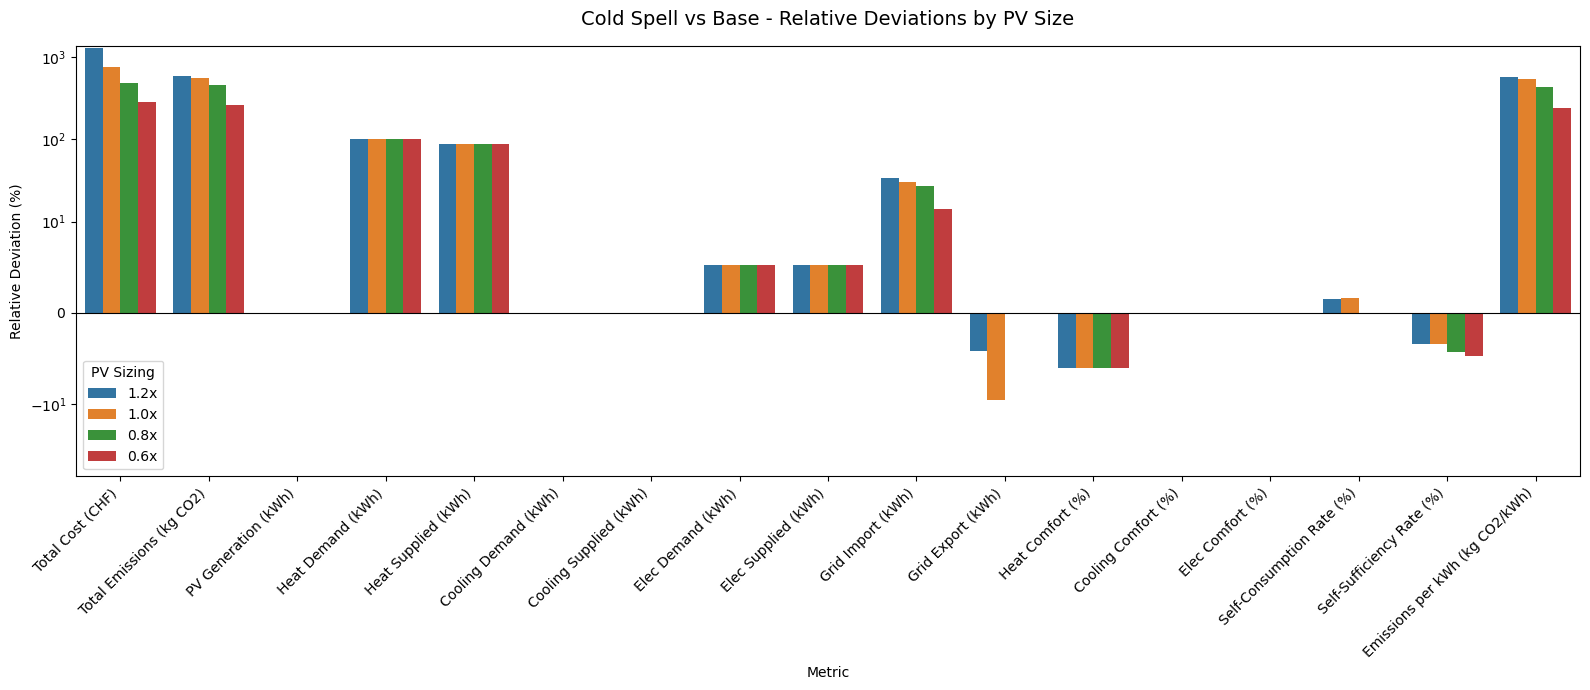

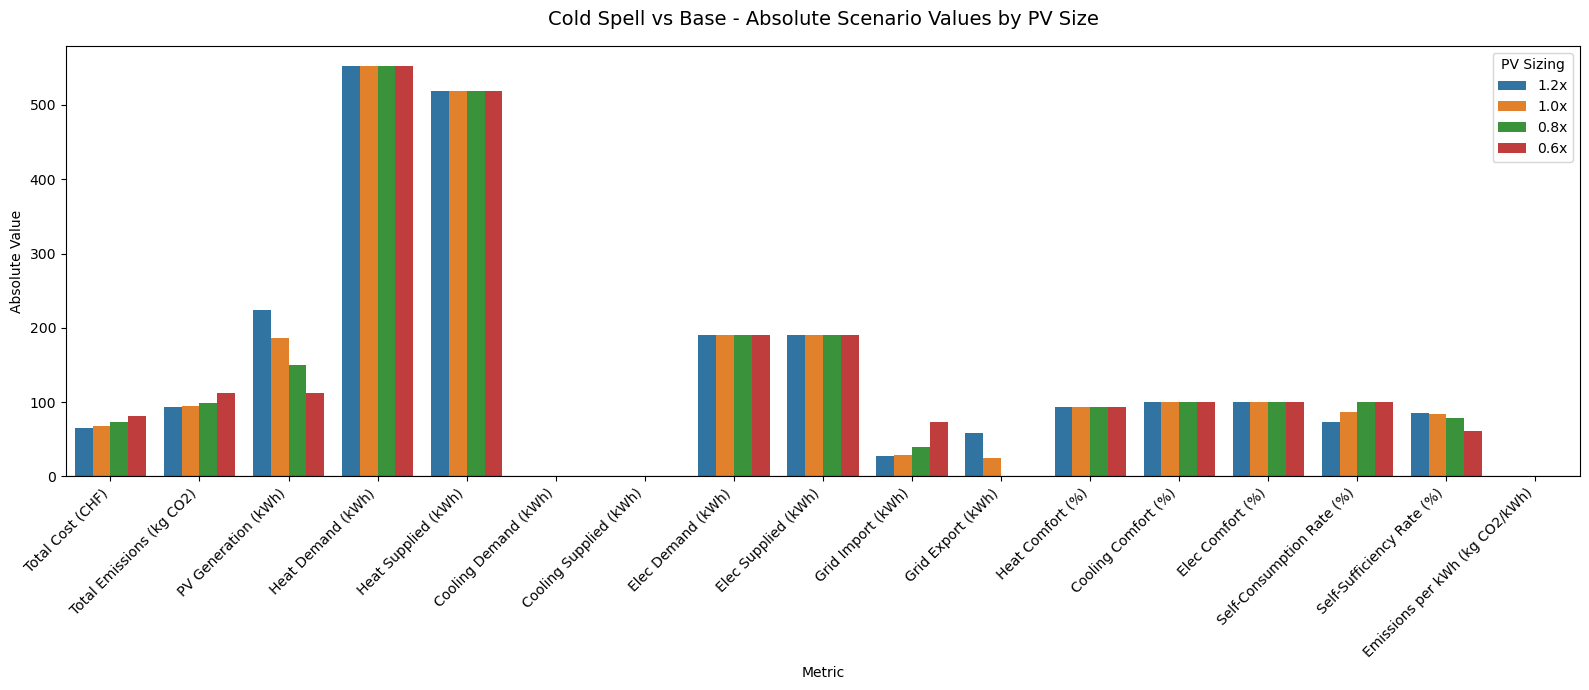

In [9]:
show_sweep_comparison(sweep_results_cs, 'Cold Spell vs Base')


## PV Breaks
what happens when PV breaks

In [10]:
sweep_results_no_pv_s = run_pv_sweep_scenario(
    duration_days           = 30,
    season                  = 'summer',  # <--- set season to summer
    pv_factor               = 0,
    battery_factor          = 1.0,
    heat_demand_factor      = 1.0,   # 2.0 = coldspell
    cooling_demand_factor   = 1.0,   # 2.0 = heatwave
    elec_demand_factor      = 1.0,
    hp_capacity_factor      = 1.0,
    chiller_capacity_factor = 1.0,
    boiler_capacity_factor  = 1.0,
    heat_storage_factor     = 1.0,
    black_out_factor        = False,
    grid_import_price_factor = 1.0,
    grid_export_price_factor = 1.0,
)



RUNNING SWEEP: PV Sizing Factor = 1.2x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=0.35  
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=2.0   
PV          : Capacity=0.0    Efficiency=1.0   
HeatPump    : Capacity=3.0    Efficiency=3.5   
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=10.0   MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.27   ExportPrice=0.08  
--------------------------------------------------


RUNNING SWEEP: PV Sizing Factor = 1.0x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=0.35  
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=2.0   
PV          : Capacity=0.0    Efficiency=1.0   
HeatPump


---  Broken PV vs Base in Summer ---

PV Sizing: 1.2x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),-18.52,366.20,+2076.96%
1,Total Emissions (kg CO2),1.06,542.52,+51219.46%
2,PV Generation (kWh),1634.40,0.00,-100.00%
3,Heat Demand (kWh),252.00,252.00,+0.00%
4,Heat Supplied (kWh),252.00,252.00,+0.00%
5,Cooling Demand (kWh),1440.00,1440.00,+0.00%
6,Cooling Supplied (kWh),1440.00,1440.00,+0.00%
7,Elec Demand (kWh),1365.50,1362.00,-0.26%
8,Elec Supplied (kWh),1365.50,1362.00,-0.26%
9,Grid Import (kWh),2.64,1356.30,+51219.46%



PV Sizing: 1.0x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),9.13,366.20,+3912.88%
1,Total Emissions (kg CO2),13.52,542.52,+3912.88%
2,PV Generation (kWh),1362.00,0.00,-100.00%
3,Heat Demand (kWh),252.00,252.00,+0.00%
4,Heat Supplied (kWh),252.00,252.00,+0.00%
5,Cooling Demand (kWh),1440.00,1440.00,+0.00%
6,Cooling Supplied (kWh),1440.00,1440.00,+0.00%
7,Elec Demand (kWh),1365.50,1362.00,-0.26%
8,Elec Supplied (kWh),1365.50,1362.00,-0.26%
9,Grid Import (kWh),33.80,1356.30,+3912.88%



PV Sizing: 0.8x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),75.89,366.20,+382.56%
1,Total Emissions (kg CO2),112.42,542.52,+382.56%
2,PV Generation (kWh),1089.60,0.00,-100.00%
3,Heat Demand (kWh),252.00,252.00,+0.00%
4,Heat Supplied (kWh),252.00,252.00,+0.00%
5,Cooling Demand (kWh),1440.00,1440.00,+0.00%
6,Cooling Supplied (kWh),1440.00,1440.00,+0.00%
7,Elec Demand (kWh),1365.50,1362.00,-0.26%
8,Elec Supplied (kWh),1365.50,1362.00,-0.26%
9,Grid Import (kWh),281.06,1356.30,+382.56%



PV Sizing: 0.6x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),145.75,366.20,+151.25%
1,Total Emissions (kg CO2),215.93,542.52,+151.25%
2,PV Generation (kWh),817.20,0.00,-100.00%
3,Heat Demand (kWh),252.00,252.00,+0.00%
4,Heat Supplied (kWh),252.00,252.00,+0.00%
5,Cooling Demand (kWh),1440.00,1440.00,+0.00%
6,Cooling Supplied (kWh),1440.00,1440.00,+0.00%
7,Elec Demand (kWh),1362.72,1362.00,-0.05%
8,Elec Supplied (kWh),1362.72,1362.00,-0.05%
9,Grid Import (kWh),539.82,1356.30,+151.25%



--- Absolute Comparison (Scenario Values) ---


PV Sizing,Metric,1.2x,1.0x,0.8x,0.6x
15,Total Cost (CHF),366.20,366.20,366.20,366.20
16,Total Emissions (kg CO2),542.52,542.52,542.52,542.52
12,PV Generation (kWh),0.00,0.00,0.00,0.00
10,Heat Demand (kWh),252.00,252.00,252.00,252.00
11,Heat Supplied (kWh),252.00,252.00,252.00,252.00
1,Cooling Demand (kWh),1440.00,1440.00,1440.00,1440.00
2,Cooling Supplied (kWh),1440.00,1440.00,1440.00,1440.00
4,Elec Demand (kWh),1362.00,1362.00,1362.00,1362.00
5,Elec Supplied (kWh),1362.00,1362.00,1362.00,1362.00
8,Grid Import (kWh),1356.30,1356.30,1356.30,1356.30


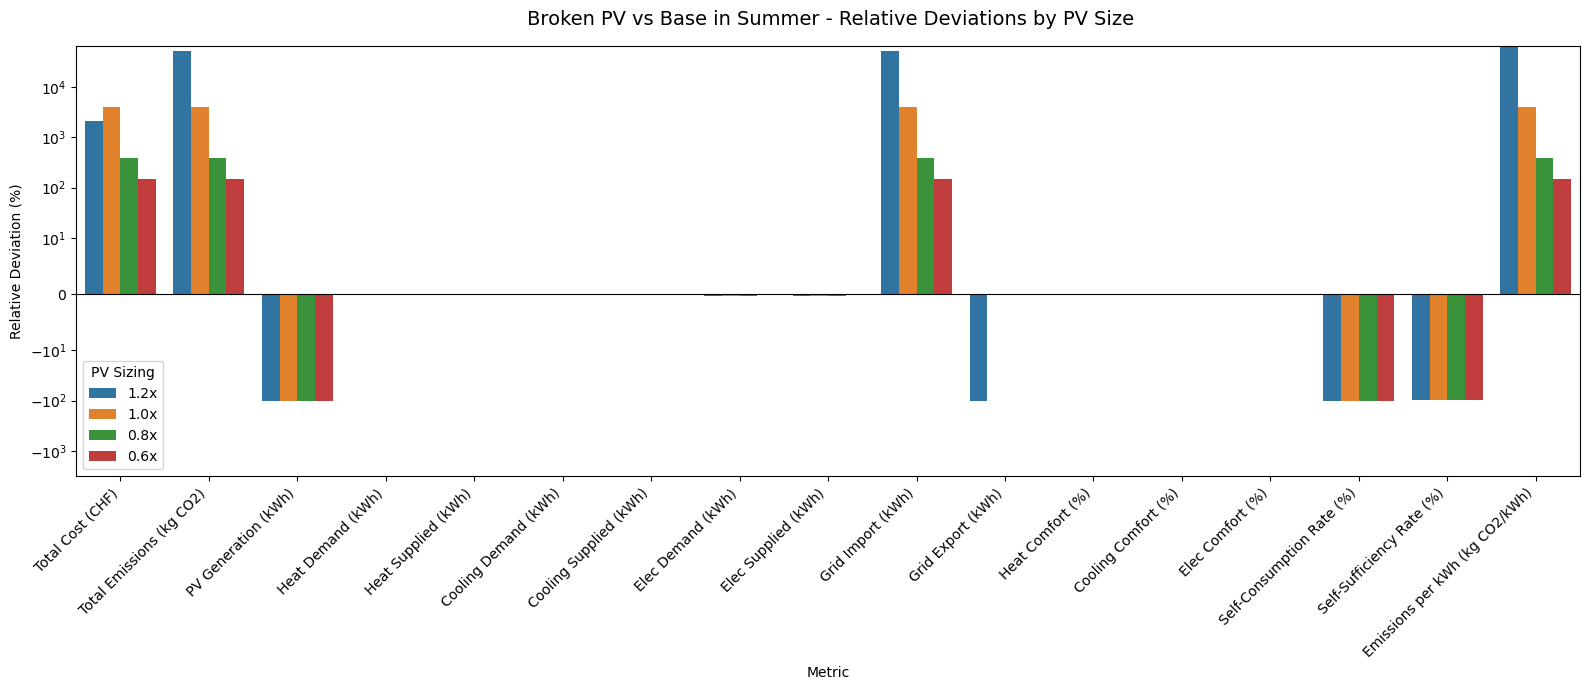

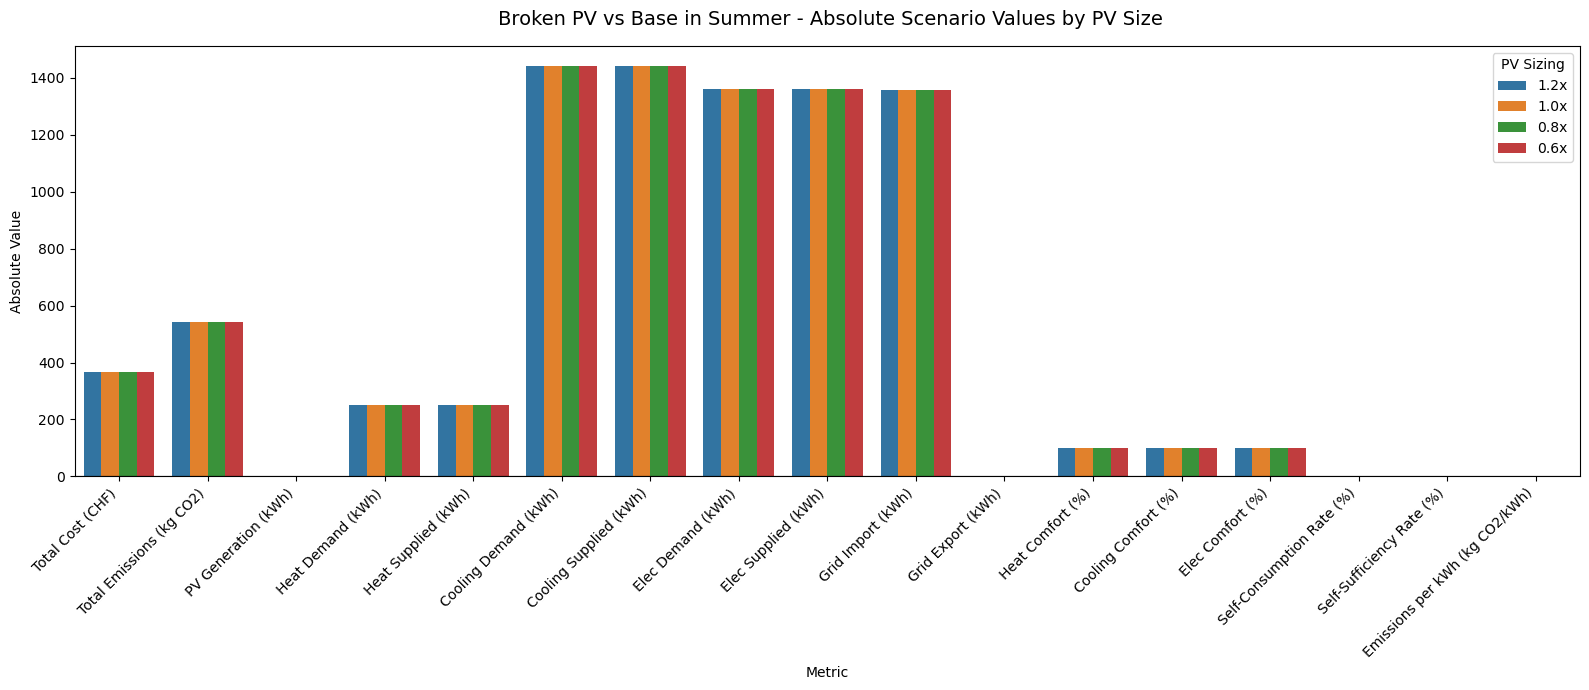

In [11]:
show_sweep_comparison(sweep_results_no_pv_s, ' Broken PV vs Base in Summer')

In [12]:
sweep_results_no_pv_w = run_pv_sweep_scenario(
    duration_days           = 30,
    season                  = 'winter',  # <--- set season to summer
    pv_factor               = 0,
    battery_factor          = 1.0,
    heat_demand_factor      = 1.0,   # 2.0 = coldspell
    cooling_demand_factor   = 1.0,   # 2.0 = heatwave
    elec_demand_factor      = 1.0,
    hp_capacity_factor      = 1.0,
    chiller_capacity_factor = 1.0,
    boiler_capacity_factor  = 1.0,
    heat_storage_factor     = 1.0,
    black_out_factor        = False,
    grid_import_price_factor = 1.0,
    grid_export_price_factor = 1.0,
)


RUNNING SWEEP: PV Sizing Factor = 1.2x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=2.875 
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacity=0.0    Efficiency=1.0   
HeatPump    : Capacity=3.0    Efficiency=3.5   
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=10.0   MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.27   ExportPrice=0.08  
--------------------------------------------------


RUNNING SWEEP: PV Sizing Factor = 1.0x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=2.875 
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacity=0.0    Efficiency=1.0   
HeatPump


--- Blackout vs Base in Summer ---

PV Sizing: 1.2x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),-18.52,366.20,+2076.96%
1,Total Emissions (kg CO2),1.06,542.52,+51219.46%
2,PV Generation (kWh),1634.40,0.00,-100.00%
3,Heat Demand (kWh),252.00,252.00,+0.00%
4,Heat Supplied (kWh),252.00,252.00,+0.00%
5,Cooling Demand (kWh),1440.00,1440.00,+0.00%
6,Cooling Supplied (kWh),1440.00,1440.00,+0.00%
7,Elec Demand (kWh),1365.50,1362.00,-0.26%
8,Elec Supplied (kWh),1365.50,1362.00,-0.26%
9,Grid Import (kWh),2.64,1356.30,+51219.46%



PV Sizing: 1.0x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),9.13,366.20,+3912.88%
1,Total Emissions (kg CO2),13.52,542.52,+3912.88%
2,PV Generation (kWh),1362.00,0.00,-100.00%
3,Heat Demand (kWh),252.00,252.00,+0.00%
4,Heat Supplied (kWh),252.00,252.00,+0.00%
5,Cooling Demand (kWh),1440.00,1440.00,+0.00%
6,Cooling Supplied (kWh),1440.00,1440.00,+0.00%
7,Elec Demand (kWh),1365.50,1362.00,-0.26%
8,Elec Supplied (kWh),1365.50,1362.00,-0.26%
9,Grid Import (kWh),33.80,1356.30,+3912.88%



PV Sizing: 0.8x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),75.89,366.20,+382.56%
1,Total Emissions (kg CO2),112.42,542.52,+382.56%
2,PV Generation (kWh),1089.60,0.00,-100.00%
3,Heat Demand (kWh),252.00,252.00,+0.00%
4,Heat Supplied (kWh),252.00,252.00,+0.00%
5,Cooling Demand (kWh),1440.00,1440.00,+0.00%
6,Cooling Supplied (kWh),1440.00,1440.00,+0.00%
7,Elec Demand (kWh),1365.50,1362.00,-0.26%
8,Elec Supplied (kWh),1365.50,1362.00,-0.26%
9,Grid Import (kWh),281.06,1356.30,+382.56%



PV Sizing: 0.6x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),145.75,366.20,+151.25%
1,Total Emissions (kg CO2),215.93,542.52,+151.25%
2,PV Generation (kWh),817.20,0.00,-100.00%
3,Heat Demand (kWh),252.00,252.00,+0.00%
4,Heat Supplied (kWh),252.00,252.00,+0.00%
5,Cooling Demand (kWh),1440.00,1440.00,+0.00%
6,Cooling Supplied (kWh),1440.00,1440.00,+0.00%
7,Elec Demand (kWh),1362.72,1362.00,-0.05%
8,Elec Supplied (kWh),1362.72,1362.00,-0.05%
9,Grid Import (kWh),539.82,1356.30,+151.25%



--- Absolute Comparison (Scenario Values) ---


PV Sizing,Metric,1.2x,1.0x,0.8x,0.6x
15,Total Cost (CHF),366.20,366.20,366.20,366.20
16,Total Emissions (kg CO2),542.52,542.52,542.52,542.52
12,PV Generation (kWh),0.00,0.00,0.00,0.00
10,Heat Demand (kWh),252.00,252.00,252.00,252.00
11,Heat Supplied (kWh),252.00,252.00,252.00,252.00
1,Cooling Demand (kWh),1440.00,1440.00,1440.00,1440.00
2,Cooling Supplied (kWh),1440.00,1440.00,1440.00,1440.00
4,Elec Demand (kWh),1362.00,1362.00,1362.00,1362.00
5,Elec Supplied (kWh),1362.00,1362.00,1362.00,1362.00
8,Grid Import (kWh),1356.30,1356.30,1356.30,1356.30


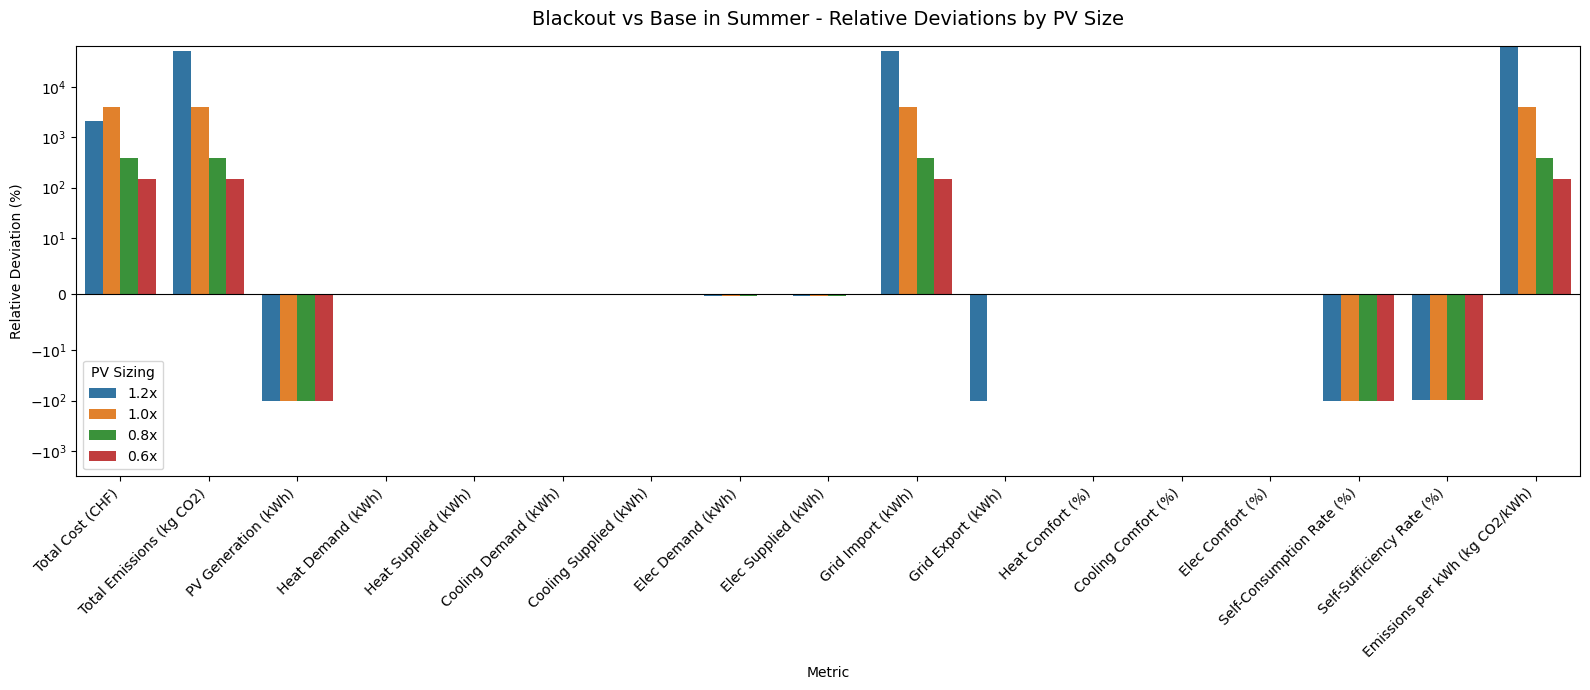

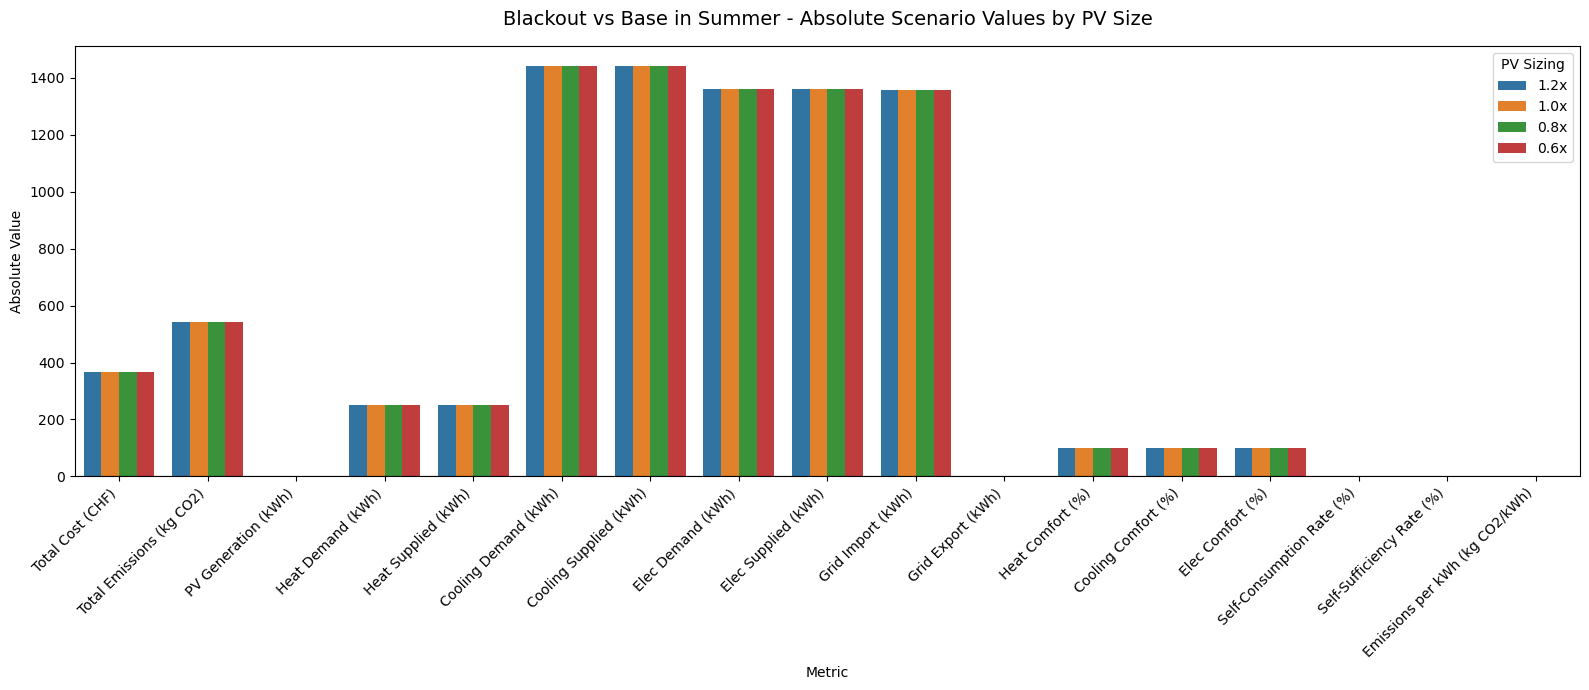

In [13]:
show_sweep_comparison(sweep_results_no_pv_s, 'Blackout vs Base in Summer')

## Grid failure/Blackout


RUNNING SWEEP: PV Sizing Factor = 1.2x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=0.35  
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=2.0   
PV          : Capacity=4.778947368421053 Efficiency=1.0   
HeatPump    : Capacity=3.0    Efficiency=3.5   
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=10.0   MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.27   ExportPrice=0.08  
--------------------------------------------------


RUNNING SWEEP: PV Sizing Factor = 1.0x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=0.35  
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=2.0   
PV          : Capacity=3.9824561403508776 Eff

,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),0.44,-0.28,-163.17%
1,Total Emissions (kg CO2),1.06,0.00,-100.00%
2,PV Generation (kWh),54.48,54.48,+0.00%
3,Heat Demand (kWh),8.40,8.40,+0.00%
4,Heat Supplied (kWh),8.40,8.40,+0.00%
5,Cooling Demand (kWh),48.00,48.00,+0.00%
6,Cooling Supplied (kWh),48.00,48.00,+0.00%
7,Elec Demand (kWh),48.90,48.90,+0.00%
8,Elec Supplied (kWh),48.90,46.26,-5.40%
9,Grid Import (kWh),2.64,0.00,-100.00%



PV Sizing: 1.0x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),1.27,0.00,-100.00%
1,Total Emissions (kg CO2),1.88,0.00,-100.00%
2,PV Generation (kWh),45.40,45.40,+0.00%
3,Heat Demand (kWh),8.40,8.40,+0.00%
4,Heat Supplied (kWh),8.40,8.40,+0.00%
5,Cooling Demand (kWh),48.00,48.00,+0.00%
6,Cooling Supplied (kWh),48.00,48.00,+0.00%
7,Elec Demand (kWh),48.90,48.90,+0.00%
8,Elec Supplied (kWh),48.90,44.21,-9.59%
9,Grid Import (kWh),4.69,0.00,-100.00%



PV Sizing: 0.8x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),2.04,0.00,-100.00%
1,Total Emissions (kg CO2),3.02,0.00,-100.00%
2,PV Generation (kWh),36.32,36.32,+0.00%
3,Heat Demand (kWh),8.40,8.40,+0.00%
4,Heat Supplied (kWh),8.40,8.40,+0.00%
5,Cooling Demand (kWh),48.00,48.00,+0.00%
6,Cooling Supplied (kWh),48.00,48.00,+0.00%
7,Elec Demand (kWh),48.90,48.90,+0.00%
8,Elec Supplied (kWh),48.90,41.34,-15.46%
9,Grid Import (kWh),7.56,0.00,-100.00%



PV Sizing: 0.6x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),3.56,0.00,-100.00%
1,Total Emissions (kg CO2),5.27,0.00,-100.00%
2,PV Generation (kWh),27.24,27.24,+0.00%
3,Heat Demand (kWh),8.40,8.40,+0.00%
4,Heat Supplied (kWh),8.40,8.40,+0.00%
5,Cooling Demand (kWh),48.00,48.00,+0.00%
6,Cooling Supplied (kWh),48.00,48.00,+0.00%
7,Elec Demand (kWh),46.12,46.12,+0.00%
8,Elec Supplied (kWh),46.12,32.94,-28.57%
9,Grid Import (kWh),13.18,0.00,-100.00%



--- Absolute Comparison (Scenario Values) ---


PV Sizing,Metric,1.2x,1.0x,0.8x,0.6x
15,Total Cost (CHF),-0.28,0.00,0.00,0.00
16,Total Emissions (kg CO2),0.00,0.00,0.00,0.00
12,PV Generation (kWh),54.48,45.40,36.32,27.24
10,Heat Demand (kWh),8.40,8.40,8.40,8.40
11,Heat Supplied (kWh),8.40,8.40,8.40,8.40
1,Cooling Demand (kWh),48.00,48.00,48.00,48.00
2,Cooling Supplied (kWh),48.00,48.00,48.00,48.00
4,Elec Demand (kWh),48.90,48.90,48.90,46.12
5,Elec Supplied (kWh),46.26,44.21,41.34,32.94
8,Grid Import (kWh),0.00,0.00,0.00,0.00


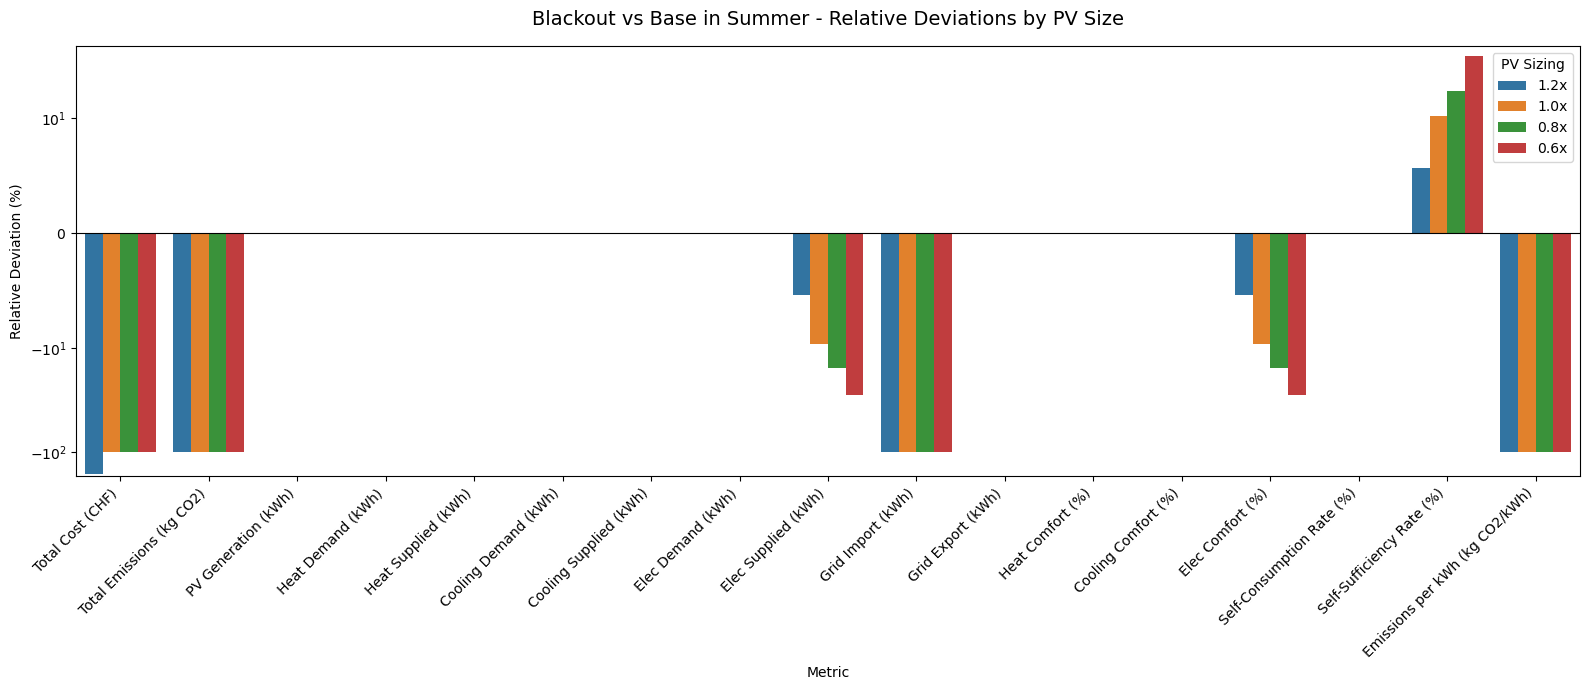

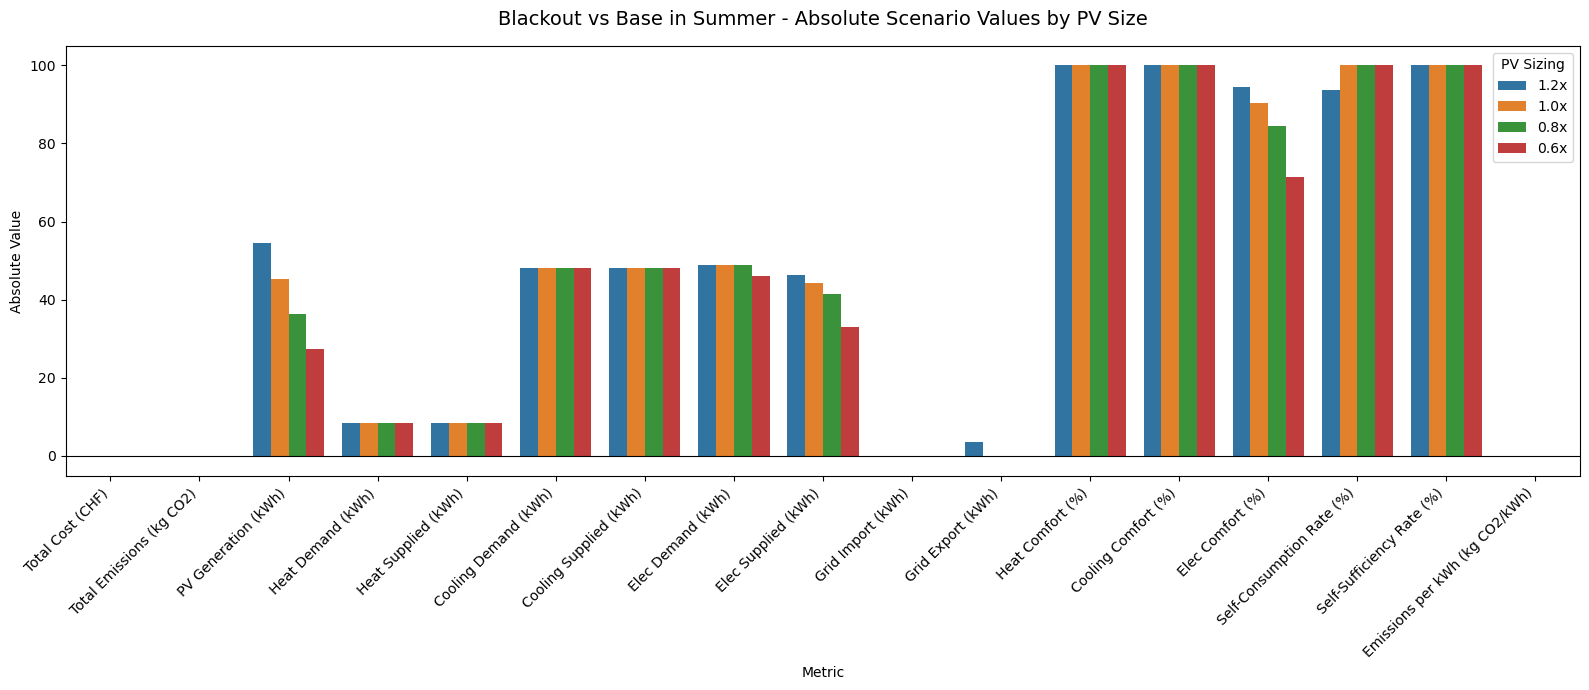

In [14]:
sweep_results_bo = run_pv_sweep_scenario(
    duration_days           = 1,
    season                  = 'summer',  # <--- set season to summer
    pv_factor               = 1,
    battery_factor          = 1.0,
    heat_demand_factor      = 1.0,   # 2.0 = coldspell
    cooling_demand_factor   = 1.0,   # 2.0 = heatwave
    elec_demand_factor      = 1.0,
    hp_capacity_factor      = 1.0,
    chiller_capacity_factor = 1.0,
    boiler_capacity_factor  = 1.0,
    heat_storage_factor     = 1.0,
    black_out_factor        = True,
    grid_import_price_factor = 1.0,
    grid_export_price_factor = 1.0,
)
show_sweep_comparison(sweep_results_bo, 'Blackout vs Base in Summer')


RUNNING SWEEP: PV Sizing Factor = 1.2x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=2.875 
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacity=7.186813186813186 Efficiency=1.0   
HeatPump    : Capacity=3.0    Efficiency=3.5   
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=10.0   MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.27   ExportPrice=0.08  
--------------------------------------------------


RUNNING SWEEP: PV Sizing Factor = 1.0x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=2.875 
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacity=5.989010989010988 Effi

,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),0.83,-0.18,-121.57%
1,Total Emissions (kg CO2),2.82,1.33,-52.80%
2,PV Generation (kWh),56.06,56.06,+0.00%
3,Heat Demand (kWh),69.00,69.00,+0.00%
4,Heat Supplied (kWh),69.00,69.00,+0.00%
5,Cooling Demand (kWh),0.00,0.00,+0.00%
6,Cooling Supplied (kWh),0.00,0.00,+0.00%
7,Elec Demand (kWh),45.86,45.86,+0.00%
8,Elec Supplied (kWh),45.86,42.13,-8.13%
9,Grid Import (kWh),3.73,0.00,-100.00%



PV Sizing: 1.0x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),1.52,0.51,-66.32%
1,Total Emissions (kg CO2),2.82,1.33,-52.80%
2,PV Generation (kWh),46.71,46.71,+0.00%
3,Heat Demand (kWh),69.00,69.00,+0.00%
4,Heat Supplied (kWh),69.00,69.00,+0.00%
5,Cooling Demand (kWh),0.00,0.00,+0.00%
6,Cooling Supplied (kWh),0.00,0.00,+0.00%
7,Elec Demand (kWh),45.86,45.86,+0.00%
8,Elec Supplied (kWh),45.86,42.13,-8.13%
9,Grid Import (kWh),3.73,0.00,-100.00%



PV Sizing: 0.8x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),2.23,1.00,-55.25%
1,Total Emissions (kg CO2),3.16,1.33,-57.84%
2,PV Generation (kWh),37.37,37.37,+0.00%
3,Heat Demand (kWh),69.00,69.00,+0.00%
4,Heat Supplied (kWh),69.00,69.00,+0.00%
5,Cooling Demand (kWh),0.00,0.00,+0.00%
6,Cooling Supplied (kWh),0.00,0.00,+0.00%
7,Elec Demand (kWh),45.86,45.86,+0.00%
8,Elec Supplied (kWh),45.86,41.28,-9.97%
9,Grid Import (kWh),4.57,0.00,-100.00%



PV Sizing: 0.6x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),4.36,1.00,-77.05%
1,Total Emissions (kg CO2),6.31,1.33,-78.86%
2,PV Generation (kWh),28.03,28.03,+0.00%
3,Heat Demand (kWh),69.00,69.00,+0.00%
4,Heat Supplied (kWh),69.00,69.00,+0.00%
5,Cooling Demand (kWh),0.00,0.00,+0.00%
6,Cooling Supplied (kWh),0.00,0.00,+0.00%
7,Elec Demand (kWh),45.86,45.86,+0.00%
8,Elec Supplied (kWh),45.86,33.43,-27.11%
9,Grid Import (kWh),12.43,0.00,-100.00%



--- Absolute Comparison (Scenario Values) ---


PV Sizing,Metric,1.2x,1.0x,0.8x,0.6x
15,Total Cost (CHF),-0.18,0.51,1.00,1.00
16,Total Emissions (kg CO2),1.33,1.33,1.33,1.33
12,PV Generation (kWh),56.06,46.71,37.37,28.03
10,Heat Demand (kWh),69.00,69.00,69.00,69.00
11,Heat Supplied (kWh),69.00,69.00,69.00,69.00
1,Cooling Demand (kWh),0.00,0.00,0.00,0.00
2,Cooling Supplied (kWh),0.00,0.00,0.00,0.00
4,Elec Demand (kWh),45.86,45.86,45.86,45.86
5,Elec Supplied (kWh),42.13,42.13,41.28,33.43
8,Grid Import (kWh),0.00,0.00,0.00,0.00


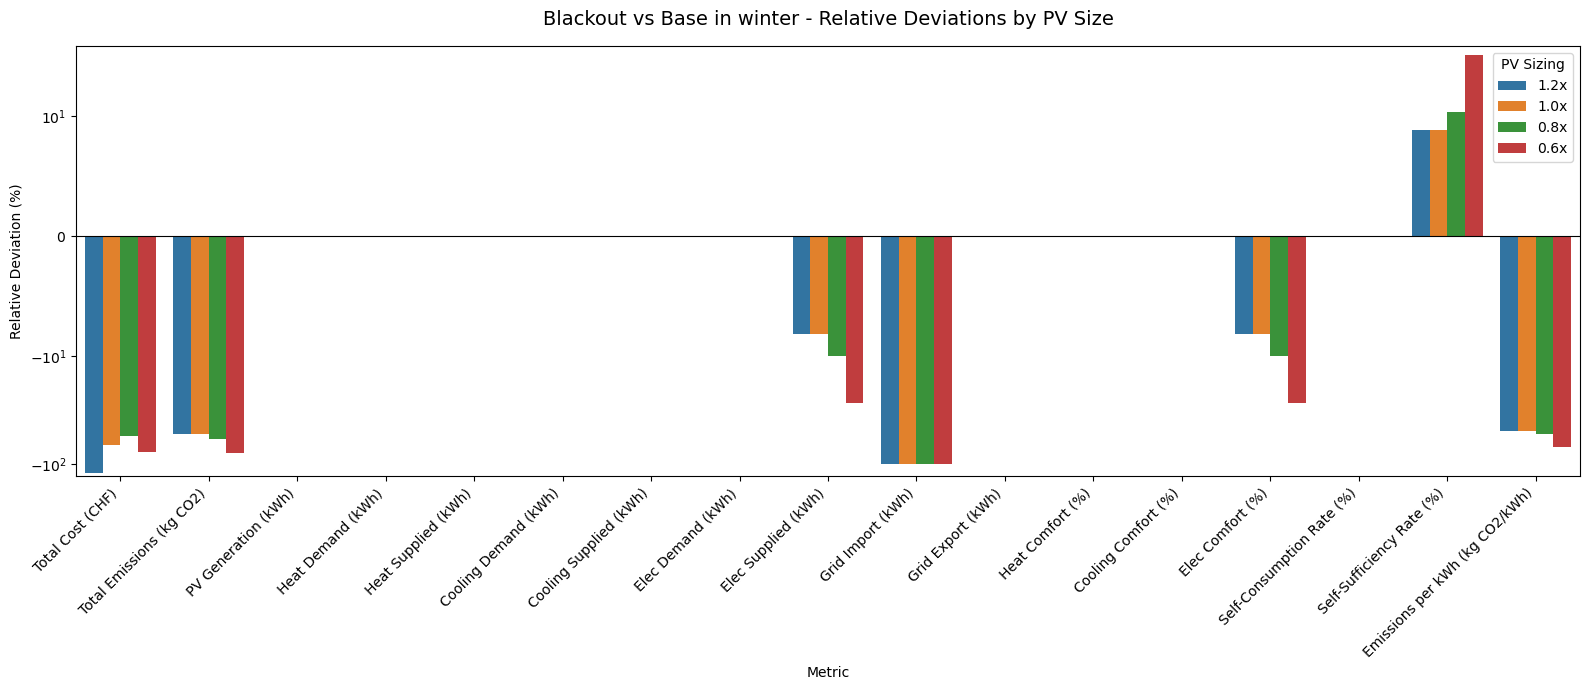

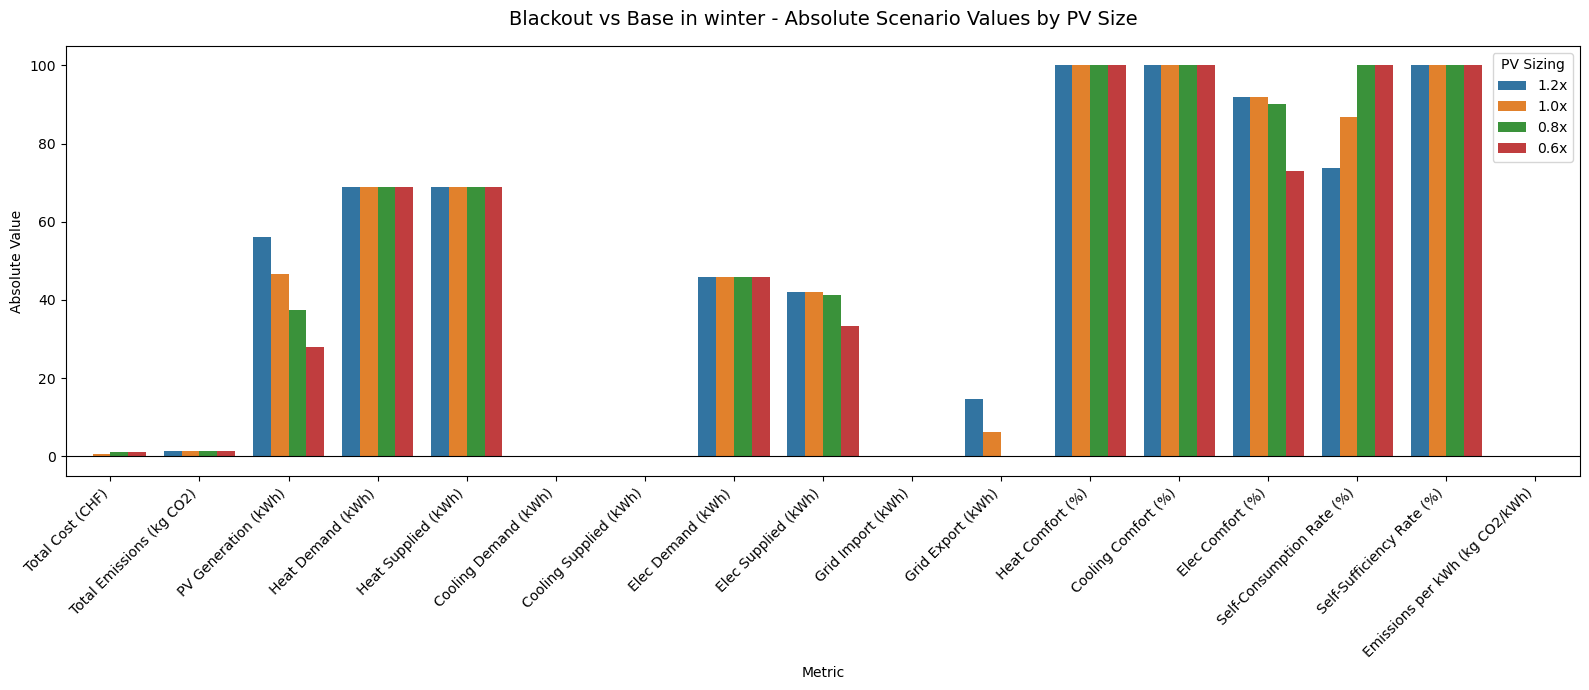

In [15]:
sweep_results_bo_w = run_pv_sweep_scenario(
    duration_days           = 1,
    season                  = 'winter',  # <--- set season to summer
    pv_factor               = 1,
    battery_factor          = 1.0,
    heat_demand_factor      = 1.0,   # 2.0 = coldspell
    cooling_demand_factor   = 1.0,   # 2.0 = heatwave
    elec_demand_factor      = 1.0,
    hp_capacity_factor      = 1.0,
    chiller_capacity_factor = 1.0,
    boiler_capacity_factor  = 1.0,
    heat_storage_factor     = 1.0,
    black_out_factor        = True,
    grid_import_price_factor = 1.0,
    grid_export_price_factor = 1.0,
)
show_sweep_comparison(sweep_results_bo_w, 'Blackout vs Base in winter')

## Economic Depression
Increased Electricity and Gas prices


RUNNING SWEEP: PV Sizing Factor = 1.2x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=2.875 
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacity=7.186813186813186 Efficiency=1.0   
HeatPump    : Capacity=3.0    Efficiency=3.5   
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=10.0   MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.81   ExportPrice=0.24  
--------------------------------------------------


RUNNING SWEEP: PV Sizing Factor = 1.0x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=2.875 
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacity=5.989010989010988 Effi

,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),124.96,174.87,+39.94%
1,Total Emissions (kg CO2),354.97,354.97,+0.00%
2,PV Generation (kWh),5605.71,5605.71,+0.00%
3,Heat Demand (kWh),6900.00,6900.00,+0.00%
4,Heat Supplied (kWh),6900.00,6900.00,+0.00%
5,Cooling Demand (kWh),0.00,0.00,+0.00%
6,Cooling Supplied (kWh),0.00,0.00,+0.00%
7,Elec Demand (kWh),4500.86,4500.86,+0.00%
8,Elec Supplied (kWh),4500.86,4500.86,+0.00%
9,Grid Import (kWh),554.10,554.10,+0.00%



PV Sizing: 1.0x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),213.16,439.48,+106.17%
1,Total Emissions (kg CO2),383.43,383.43,+0.00%
2,PV Generation (kWh),4671.43,4671.43,+0.00%
3,Heat Demand (kWh),6900.00,6900.00,+0.00%
4,Heat Supplied (kWh),6900.00,6900.00,+0.00%
5,Cooling Demand (kWh),0.00,0.00,+0.00%
6,Cooling Supplied (kWh),0.00,0.00,+0.00%
7,Elec Demand (kWh),4500.86,4500.86,+0.00%
8,Elec Supplied (kWh),4500.86,4500.86,+0.00%
9,Grid Import (kWh),625.25,625.25,+0.00%



PV Sizing: 0.8x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),330.67,792.00,+139.52%
1,Total Emissions (kg CO2),475.06,475.06,+0.00%
2,PV Generation (kWh),3737.14,3737.14,+0.00%
3,Heat Demand (kWh),6900.00,6900.00,+0.00%
4,Heat Supplied (kWh),6900.00,6900.00,+0.00%
5,Cooling Demand (kWh),0.00,0.00,+0.00%
6,Cooling Supplied (kWh),0.00,0.00,+0.00%
7,Elec Demand (kWh),4500.86,4500.86,+0.00%
8,Elec Supplied (kWh),4500.86,4500.86,+0.00%
9,Grid Import (kWh),854.32,854.32,+0.00%



PV Sizing: 0.6x Demand


,Metric,Base,Scenario,Rel. Dev. (%)
0,Total Cost (CHF),567.33,1501.99,+164.75%
1,Total Emissions (kg CO2),825.67,825.67,+0.00%
2,PV Generation (kWh),2802.86,2802.86,+0.00%
3,Heat Demand (kWh),6900.00,6900.00,+0.00%
4,Heat Supplied (kWh),6900.00,6900.00,+0.00%
5,Cooling Demand (kWh),0.00,0.00,+0.00%
6,Cooling Supplied (kWh),0.00,0.00,+0.00%
7,Elec Demand (kWh),4500.86,4500.86,+0.00%
8,Elec Supplied (kWh),4500.86,4500.86,+0.00%
9,Grid Import (kWh),1730.85,1730.85,+0.00%



--- Absolute Comparison (Scenario Values) ---


PV Sizing,Metric,1.2x,1.0x,0.8x,0.6x
15,Total Cost (CHF),174.87,439.48,792.00,1501.99
16,Total Emissions (kg CO2),354.97,383.43,475.06,825.67
12,PV Generation (kWh),5605.71,4671.43,3737.14,2802.86
10,Heat Demand (kWh),6900.00,6900.00,6900.00,6900.00
11,Heat Supplied (kWh),6900.00,6900.00,6900.00,6900.00
1,Cooling Demand (kWh),0.00,0.00,0.00,0.00
2,Cooling Supplied (kWh),0.00,0.00,0.00,0.00
4,Elec Demand (kWh),4500.86,4500.86,4500.86,4500.86
5,Elec Supplied (kWh),4500.86,4500.86,4500.86,4500.86
8,Grid Import (kWh),554.10,625.25,854.32,1730.85


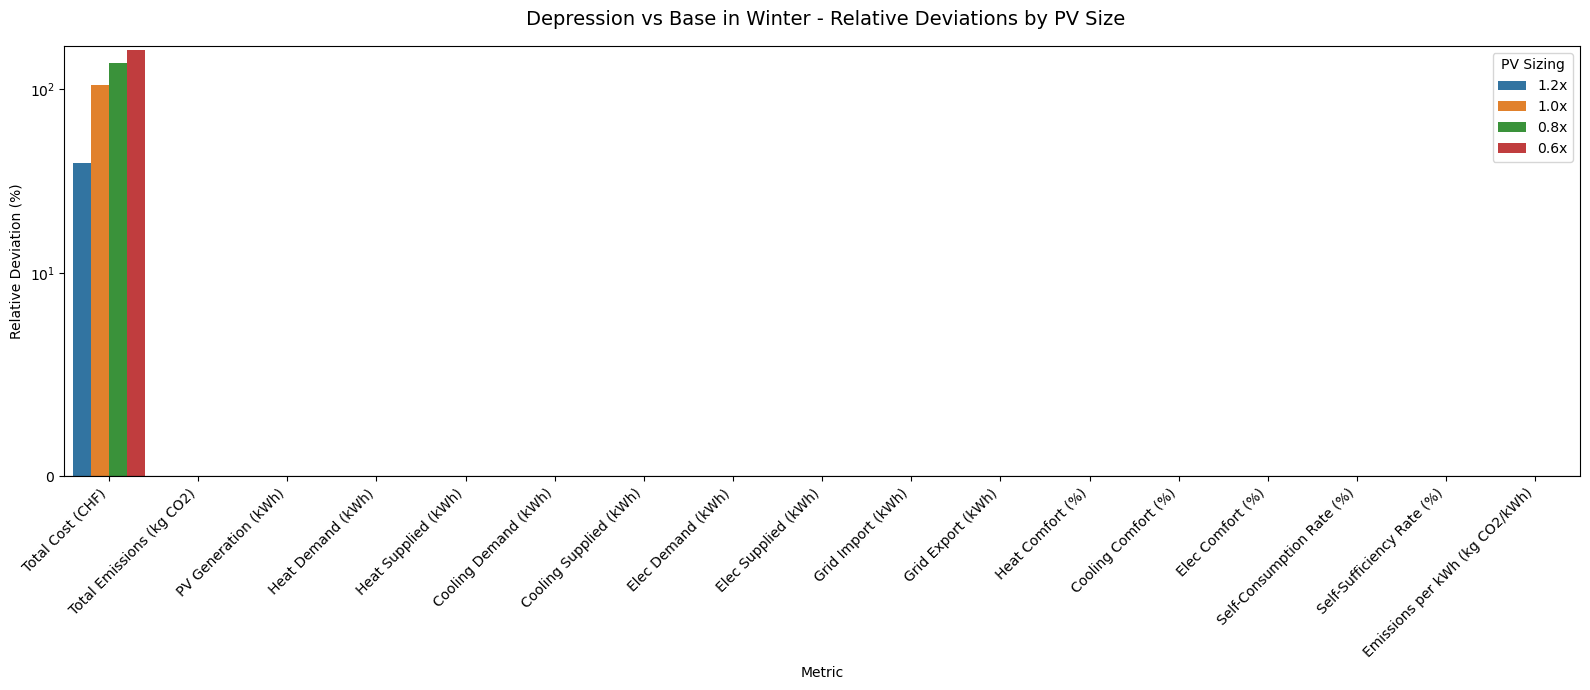

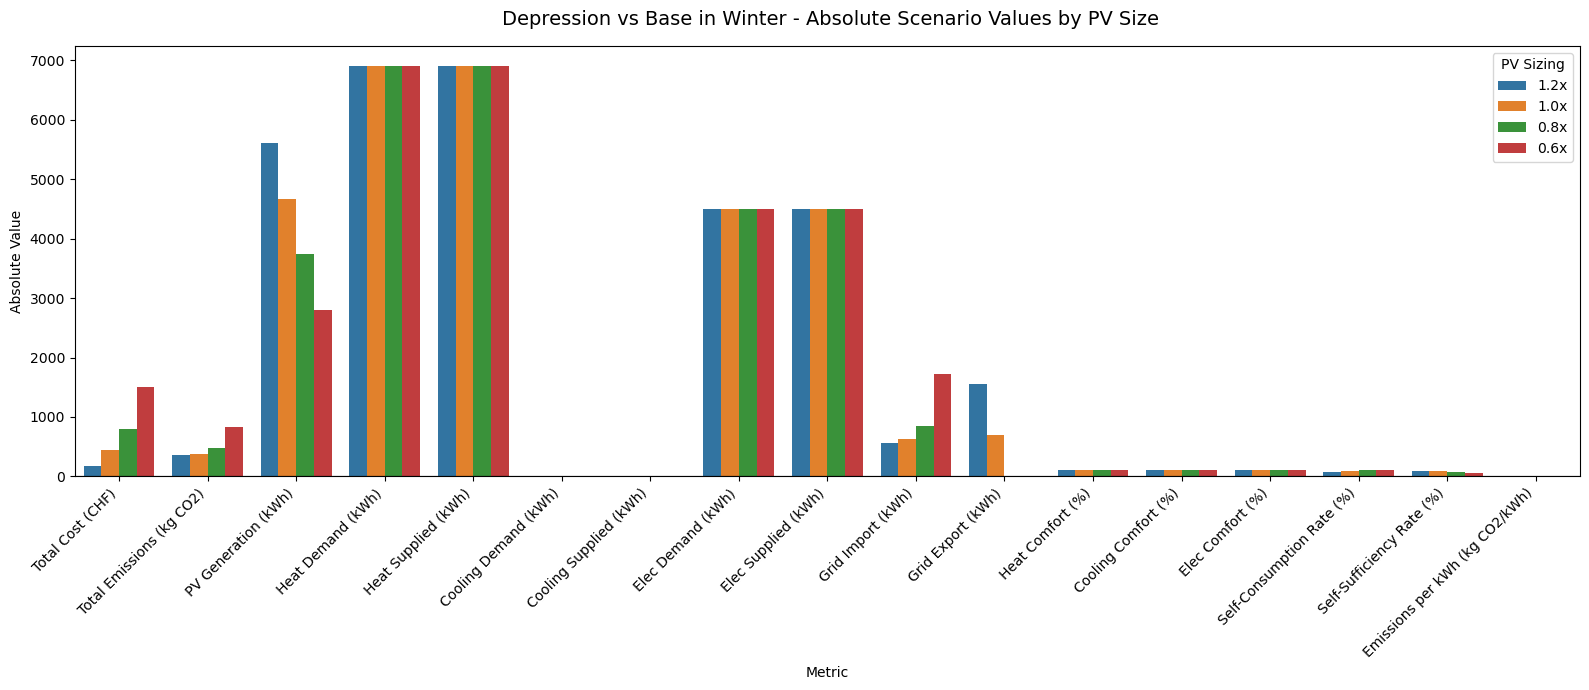

In [16]:
sweep_results_depression = run_pv_sweep_scenario(
    duration_days           = 100,
    season                  = 'winter',  # <--- set season to summer
    pv_factor               = 1,
    battery_factor          = 1.0,
    heat_demand_factor      = 1.0,   # 2.0 = coldspell
    cooling_demand_factor   = 1.0,   # 2.0 = heatwave
    elec_demand_factor      = 1.0,
    hp_capacity_factor      = 1.0,
    chiller_capacity_factor = 1.0,
    boiler_capacity_factor  = 1.0,
    heat_storage_factor     = 1.0,
    black_out_factor        = False,
    grid_import_price_factor = 3.0,
    grid_export_price_factor = 3.0,
)

show_sweep_comparison(sweep_results_depression, ' Depression vs Base in Winter')